## Implementing Regression

In [2]:
# Lets build a regression model, perform analysis and evaluate model performance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score,KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score




In [3]:
# Load the dataset
df=pd.read_csv('housing_with_ocean_proximity.csv')
df.head()

#target variable - median-house-value

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<Axes: xlabel='longitude', ylabel='latitude'>

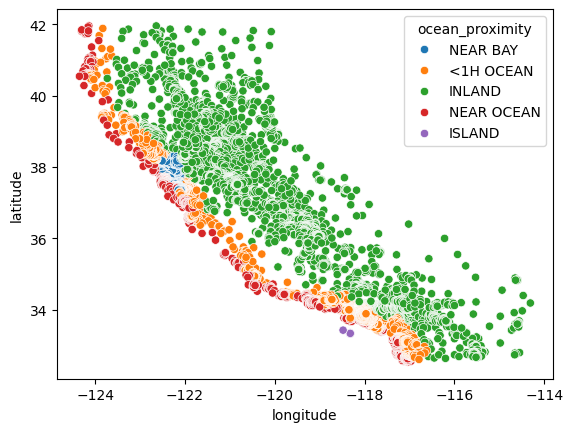

In [4]:
import seaborn as sns
sns.scatterplot(x='longitude', y='latitude', hue='ocean_proximity', data=df)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
df['total_bedrooms'].fillna(df['total_bedrooms'].mean(),inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_12788\317514307.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].mean(),inplace=True)


In [9]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [10]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [11]:
# Non numeric into numeric
# Apply get dummies to do One Hot Encoding

df=pd.get_dummies(df,drop_first=True,prefix='ocean_proximity',dtype=int)

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_INLAND      20640 non-null  int64  
 10  ocean_proximity_ISLAND      20640 non-null  int64  
 11  ocean_proximity_NEAR BAY    20640 non-null  int64  
 12  ocean_proximity_NEAR OCEAN  20640 non-null  int64  
dtypes: float64(9), int64(4)
memory 

In [13]:
# Featuure and Target Split
X=df.drop(columns=['median_house_value'])
y=df['median_house_value']  

print(X.shape)
print(y.shape)

(20640, 12)
(20640,)


In [14]:
# perform train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=25)

In [15]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(14448, 12)
(6192, 12)
(14448,)
(6192,)


In [24]:
# Perform K-Fold Cross Validation

kf=KFold(n_splits=10,random_state=25,shuffle=True)



In [ ]:
# Lets implement Linear Regression Model
lr=LinearRegression()



#Evaluate the model using Cross Validation
k_fold_score=cross_val_score(lr,X_train,y_train,scoring='r2',cv=kf)


# print the K-Fold scores  - this will give 10 scores as we have 10 folds R2 scores
print(k_fold_score)



[0.64881137 0.65725058 0.57698462 0.64449849 0.65055625 0.65034572
 0.63002596 0.63057305 0.65200656 0.67541061]


In [26]:
# print average K-Fold score

print(f'The average K-Fold score is : {k_fold_score.mean():.4f}')


The average K-Fold score is : 0.6416


In [ ]:

#Train the model
lr.fit(X_train,y_train)
lr.fit(X_test,y_test)


In [17]:
# Display the coefficients of regression and intercept values

print(lr.coef_)
print(lr.intercept_)

[-2.58373367e+04 -2.52338426e+04  1.03233105e+03 -3.17192048e+00
  5.42519495e+01 -5.02475569e+01  1.14458509e+02  3.92610841e+04
 -3.80279902e+04  1.73196698e+05 -2.12415682e+03  5.34928442e+03]
-2159112.009901056


In [18]:
# Now lets find the model predictions

y_pred_train=lr.predict(X_train)
y_pred_test=lr.predict(X_test)

In [27]:
# Lets calculate the error

print(f'Mean Squared Error Train: {mean_squared_error(y_train,y_pred_train)}')
print(f'Mean Absolute Error Train:{mean_absolute_error(y_train,y_pred_train)}')
print(f'Root Mean Square Error Train: {np.sqrt(mean_squared_error(y_train,y_pred_train))}')
print(f'R2 Score Train: {r2_score(y_train,y_pred_train)}')


print("-"*50)

print(f'Mean Squared Error Test: {mean_squared_error(y_test,y_pred_test)}')
print(f'Mean Absolute Error Test:{mean_absolute_error(y_test,y_pred_test)}')
print(f'Root Mean Square Error Test: {np.sqrt(mean_squared_error(y_test,y_pred_test))}')
print(f'R2 Score Test: {r2_score(y_test,y_pred_test)}')








# if no outlier - MSE sensitive to outlier - if no outlier there will be a slight difference between MAE AND RMSE

Mean Squared Error Train: 4794116151.641359
Mean Absolute Error Train:49930.644721911645
Root Mean Square Error Train: 69239.55626404143
R2 Score Train: 0.6395252987475619
--------------------------------------------------
Mean Squared Error Test: 4650029092.224349
Mean Absolute Error Test:49981.880393832245
Root Mean Square Error Test: 68191.12179913415
R2 Score Test: 0.6517071127685918


 There is a slight underfitting in the model - The r2 scores have improved for Test data - but the difference between the MAE and RMSE 
 indicate there are outliers in the data - as the difference is huge 

In [ ]:
# Now lets visualize the model predictions



plt.scatter(X_train,y_train,color='b',label='Actual')
plt.scatter(X_train,y_pred_train,color='r',label='Predicted')
plt.xlabel('Features')
plt.ylabel('Target')
plt.title('Train Data: Actual vs Predicted')
plt.legend()
plt.show()


AttributeError: 'DataFrame' object has no attribute 'ravel'